# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import bs4 as bs
import yfinance as yf
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Predict the sign instead of the price but also save the predicted prices so that we could then choose the stocks with the highest returns.

Start with only 1 horizon - but at the end of the lab, one can redo the horizon.

If we do with fewer stocks than 500, then don't compare o S&P500.

They predict the probab of the sign --> and then they take the one with the highest probab 

### Web-scrapping

In [130]:
url = 'http://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/111.0.0.0 Safari/537.36'
}

resp = requests.get(url, headers=headers) 
soup = bs.BeautifulSoup(resp.text, 'lxml')

table = soup.find('table', {'id': 'constituents'})
tickers = []

for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')
    if cols:  
        ticker = cols[0].text.strip()
        tickers.append(ticker)

print(len(tickers))  
print(f'Examplary tickers scrapped: {tickers[:10]}')

503
Examplary tickers scrapped: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [131]:
### List of tickers as input in the yfinance package (an API that gives access to Yahoo Finance data)
tickers = [s.replace('.','-') for s in tickers] + ['^SPX']
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2020, 12, 31)
data = yf.download(tickers, start=start, end=None)
data.head()

C:\Users\lasko\AppData\Local\Temp\ipykernel_41732\2162137305.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  504 of 504 completed


Price           Close                                                      \
Ticker              A      AAPL ABBV ABNB        ABT      ACGL        ACN   
Date                                                                        
2010-01-04  19.891680  6.424606  NaN  NaN  18.496670  7.601905  31.492174   
2010-01-05  19.675604  6.435712  NaN  NaN  18.347231  7.576549  31.686815   
2010-01-06  19.605696  6.333344  NaN  NaN  18.449114  7.543795  32.023655   
2010-01-07  19.580271  6.321636  NaN  NaN  18.601957  7.499420  31.993713   
2010-01-08  19.573919  6.363664  NaN  NaN  18.697054  7.484628  31.866463   

Price                                                                         \
Ticker           ADBE        ADI        ADM        ADP       ADSK        AEE   
Date                                                                           
2010-01-04  37.090000  21.975164  20.614496  25.898790  25.670000  15.615405   
2010-01-05  37.700001  21.940477  20.725845  25.759712  25.280001  15.553534   
2010-01-06  37.619999  21.898838  20.673452  25.699253  25.340000  15.446655   
2010-01-07  36.889999  21.725367  20.457287  25.687147  25.480000  15.300398   
2010-01-08  36.689999  21.850269  20.201809  25.650871  26.260000  15.193521   

Price                                                                        \
Ticker            AEP       AES        AFL        AIG        AIZ        AJG   
Date                                                                          
2010-01-04  19.011015  8.940196  16.221989  18.885641  22.143976  15.014436   
2010-01-05  18.793381  8.848634  16.692577  18.531809  22.804762  14.933747   
2010-01-06  18.983812  8.757075  16.839222  18.411751  22.738684  14.940477   
2010-01-07  19.147041  8.763615  17.019957  18.057932  23.017691  14.846334   
2010-01-08  19.375568  9.012136  16.849451  18.538126  23.032370  14.886683   

Price                                                                          \
Ticker           AKAM        ALB   ALGN        ALL ALLE       AMAT AMCR   AMD   
Date                                                                            
2010-01-04  25.920000  30.328428  18.50  21.307915  NaN  11.048754  NaN  9.70   
2010-01-05  26.690001  30.272680  18.01  21.658258  NaN  10.963763  NaN  9.71   
2010-01-06  26.469999  30.328428  17.48  21.665268  NaN  10.940587  NaN  9.57   
2010-01-07  26.480000  30.113424  17.43  21.777370  NaN  10.824687  NaN  9.47   
2010-01-08  26.480000  30.567295  17.66  21.868456  NaN  11.241918  NaN  9.43   

Price                                                                \
Ticker            AME       AMGN        AMP        AMT    AMZN ANET   
Date                                                                  
2010-01-04  15.491839  39.592060  28.590206  32.086201  6.6950  NaN   
2010-01-05  15.423602  39.249096  29.256926  32.617779  6.7345  NaN   
2010-01-06  15.439656  38.954151  29.665565  32.787586  6.6125  NaN   
2010-01-07  15.479795  38.597462  29.887815  32.698982  6.5000  NaN   
2010-01-08  15.780798  38.940422  29.995342  32.765430  6.6760  NaN   

Price                                                                         \
Ticker            AON       AOS        APA        APD       APH APO APP APTV   
Date                                                                           
2010-01-04  32.125519  5.849097  78.900406  51.808647  5.049890 NaN NaN  NaN   
2010-01-05  31.922304  5.774361  79.831970  51.378777  4.944364 NaN NaN  NaN   
2010-01-06  31.913828  5.776984  81.083992  50.955139  4.963050 NaN NaN  NaN   
2010-01-07  31.820707  5.794028  79.854332  50.662315  4.930075 NaN NaN  NaN   
2010-01-08  32.083191  5.879254  79.436996  50.986267  4.966348 NaN NaN  NaN   

Price                                                                        \
Ticker            ARE        ATO        AVB      AVGO        AVY        AWK   
Date                                                                          
2010-01-04  3

In [132]:
new_df = data[['Close', 'Volume']]

## Task #1 : Basic manipulation and descriptive statistics
### Describe the sample (optional)

In [133]:
missing_values = new_df.isna().sum()
print(missing_values)

Price   Ticker
Close   A            0
        AAPL         0
        ABBV       754
        ABNB      2754
        ABT          0
        ACGL         0
        ACN          0
        ADBE         0
        ADI          0
        ADM          0
        ADP          0
        ADSK         0
        AEE          0
        AEP          0
        AES          0
        AFL          0
        AIG          0
        AIZ          0
        AJG          0
        AKAM         0
        ALB          0
        ALGN         0
        ALL          0
        ALLE       976
        AMAT         0
        AMCR       596
        AMD          0
        AME          0
        AMGN         0
        AMP          0
        AMT          0
        AMZN         0
        ANET      1113
        AON          0
        AOS          0
        APA          0
        APD          0
        APH          0
        APO        312
        APP       2839
        APTV       474
        ARE          0
        ATO        

In [134]:
new_df.describe()

Price         Close                                                      \
Ticker            A         AAPL         ABBV         ABNB          ABT   
count   3964.000000  3964.000000  3210.000000  1210.000000  3964.000000   
mean      71.121089    74.682753    84.927959   138.376748    61.963198   
std       44.127813    71.826868    51.381772    24.455455    37.191327   
min       17.139887     5.765363    20.204021    82.489998    15.821707   
25%       33.244464    18.098378    42.395792   121.172499    29.900280   
50%       60.799326    37.436153    68.291046   136.000000    48.292257   
75%      117.508904   140.204853   129.183826   152.722496   100.470083   
max      174.067642   258.103729   244.380005   216.839996   138.949768   

Price                                                                    \
Ticker         ACGL          ACN         ADBE          ADI          ADM   
count   3964.000000  3964.000000  3964.000000  3964.000000  3964.000000   
mean      34.877243   157.102602   234.976665    92.579845    39.599660   
std       25.468945   105.581769   193.454039    64.076713    17.506827   
min        7.346220    27.517168    22.690001    18.387814    16.226223   
25%       17.356275    64.386629    57.114999    37.939269    26.499058   
50%       27.411235   127.543533   175.200005    73.897507    34.701885   
75%       41.135871   262.033424   398.580002   149.008694    50.750351   
max      109.220207   394.312805   688.369995   254.623001    89.422707   

Price                                                                    \
Ticker          ADP         ADSK          AEE          AEP          AES   
count   3964.000000  3964.000000  3964.000000  3964.000000  3964.000000   
mean     121.462428   133.973083    49.141018    54.897548    12.028748   
std       82.287614    94.290366    24.993356    24.998019     5.031994   
min       23.726585    22.950001    13.555287    17.276278     5.820609   
25%       51.723192    45.265000    24.927480    31.243995     8.235814   
50%       96.193359   113.574997    45.729572    52.667046     9.552384   
75%      191.067413   212.397503    71.320217    74.902126    15.408946   
max      323.504852   342.269989   104.879997   115.660004    25.973694   

Price                                                                    \
Ticker          AFL          AIG          AIZ          AJG         AKAM   
count   3964.000000  3964.000000  3964.000000  3964.000000  3964.000000   
mean      40.837469    43.726188    91.296468    96.294671    70.310161   
std       25.361842    15.771432    53.352313    86.995815    26.504894   
min       11.192985    14.001527    21.850285    14.792544    18.650000   
25%       22.718858    32.228755    49.169521    34.948991    48.197500   
50%       32.196138    43.928137    82.520584    56.673666    69.820000   
75%       51.087888    50.919422   126.662449   148.145782    92.389999   
max      113.070000    86.750175   225.285370   347.325409   128.320007   

Price                                                                    \
Ticker          ALB         ALGN          ALL         ALLE         AMAT   
count   3964.000000  3964.000000  3964.000000  2988.000000  3964.000000   
mean      92.253923   186.066592    79.324659    90.463058    61.620903   
std       60.026819   166.371920    48.443451    30.882509    59.663216   
min       27.756590    13.270000    16.689438    35.902145     7.919183   
25%       51.673223    50.787500    41.250734    61.297579    14.351546   
50%       70.751732   166.330002    75.621178    91.388195    37.239069   
75%      108.534344   273.400002   107.407913   114.174585   108.349644   
max      311.628021   729.919983   214.649994   179.330002   251.861725   

Price                                                                    \
Ticker         AMCR          AMD          AME         AMGN          AMP   
count   3368.000000  3964.000000  3964.000000  3964.000000  3964.000000   
mean       7.907203 

- What is the average trading volume for Apple stock?

In [135]:
avg_trading_vol = new_df['Volume']['AAPL'].mean()
print(f'The avg trading volume of Apple over the researched period: {avg_trading_vol:,.2f}')

The avg trading volume of Apple over the researched period: 221,630,713.04


- What is the maximum trading volume for S&P500?

In [136]:
max_trading_vol = new_df['Volume']['^SPX'].max()
print(f'The maximum trading volume for S&P500 over the researched period: {max_trading_vol:,.2f}')

The maximum trading volume for S&P500 over the researched period: 10,617,810,000.00


- Which security is traded the most? Comment on your answer

In [137]:
avg_volume = new_df['Volume'].mean()
avg_volume = avg_volume.drop('^SPX', errors='ignore')

# Ticker with highest average volume
most_traded_ticker = avg_volume.idxmax()
max_avg_volume = avg_volume.max()

print(f"The most actively traded security is {most_traded_ticker}, "
      f"with an average daily volume of {max_avg_volume:,.0f} shares.")

The most actively traded security is NVDA, with an average daily volume of 484,256,173 shares.


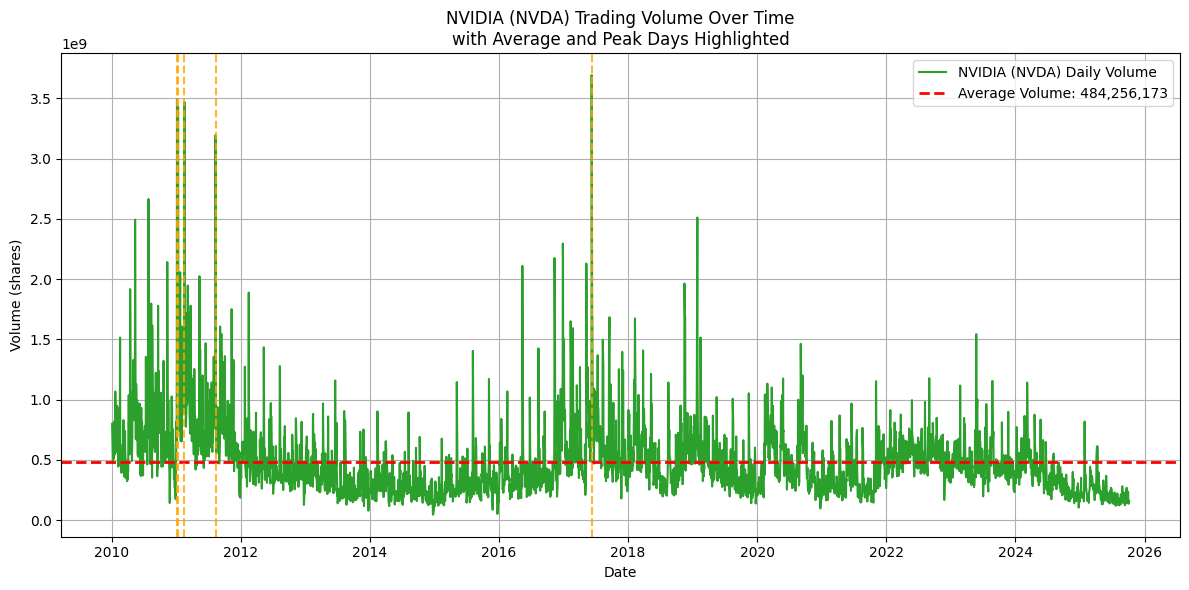

In [138]:
# Extract NVDA volume
nvda_volume = new_df['Volume']['NVDA']

# Compute average volume
avg_volume_nvda = nvda_volume.mean()

# Find top 5 highest-volume days
top_peaks = nvda_volume.nlargest(5)

# Plot volume line
plt.figure(figsize=(12,6))
plt.plot(nvda_volume, label='NVIDIA (NVDA) Daily Volume', color='tab:green')

# Add average line
plt.axhline(y=avg_volume_nvda, color='red', linestyle='--', linewidth=2,
            label=f'Average Volume: {avg_volume_nvda:,.0f}')

# Add vertical lines for peak days
for date, vol in top_peaks.items():
    plt.axvline(x=date, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)

# Final formatting
plt.title('NVIDIA (NVDA) Trading Volume Over Time\nwith Average and Peak Days Highlighted')
plt.xlabel('Date')
plt.ylabel('Volume (shares)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**NVIDIA** (NVDA) emerges as **the most traded stock** in our dataset, which is consistent with its elevated prominence over recent years. As a **major player in the semiconductor and AI hardware space**, NVDA draws strong institutional and retail interest.

As displayed by the graph, the daily trading volume is **highly volatile day-to-day**. Clusters of heavy activity can be identified, with orange dashed vertical lines marking the top 5 peak-volume days.

NVDA’s dominance in trading volume is largely driven by its **central role in the artificial intelligence and data center sectors**, which have captured significant investor attention - especially following the explosion of **interest in generative AI** technologies such as ChatGPT. The rapid adoption of AI models has created **massive demand for NVIDIA’s high-performance GPUs**, positioning the company as the hardware backbone of the AI revolution. 

Its large market capitalization and inclusion in major indices make it a **highly liquid stock**, attracting institutional funds. In addition, its **high volatility and frequent news catalysts**, such as earnings announcements, product releases and AI-related developments, draw substantial activity from both professional and retail traders.

This combination of liquidity, volatility and thematic relevance explains why NVDA consistently ranks among the most heavily traded stocks in the S&P 500. However, much of its average trading volume is concentrated around specific event-driven spikes, suggesting that while NVDA maintains consistently high investor interest, its **trading activity is particularly elevated during major news or market-moving periods**.

### Plot the time series of volumes for all stocks (raw and normalized)

For readibility purposes, we'll plot **Top 8 most traded stocks in the researched period**:

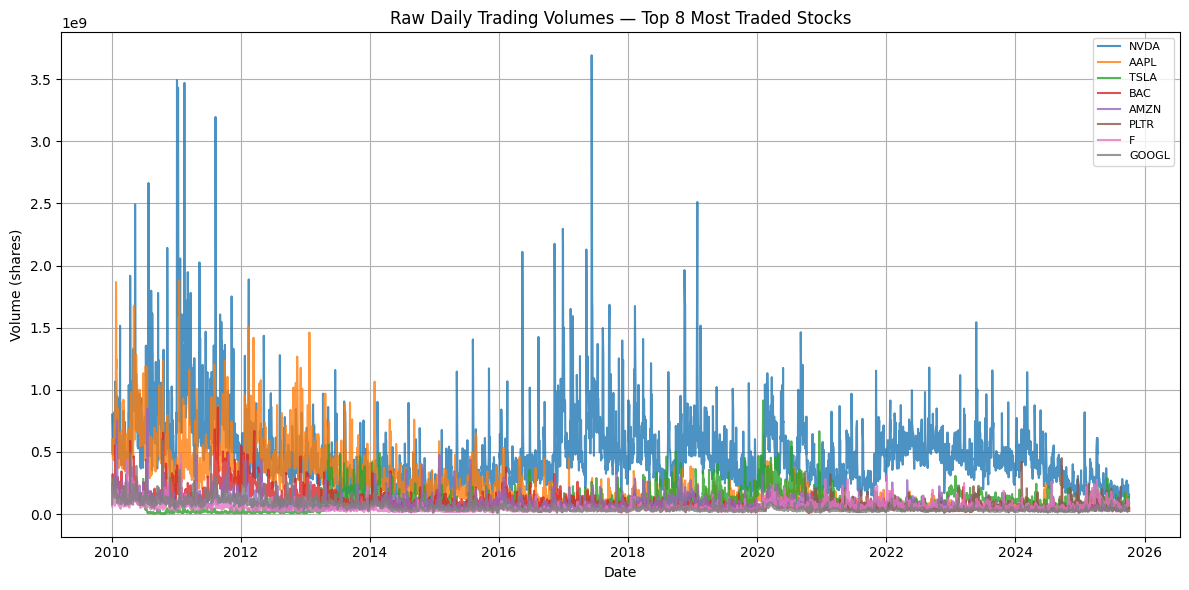

In [139]:
volume_df = new_df['Volume'].drop(columns='^SPX', errors='ignore')

# Top 10 stocks by average volume
avg_volumes = volume_df.mean().sort_values(ascending=False)
top8_tickers = avg_volumes.head(8).index

top8_volume = volume_df[top8_tickers]

# RAW trading volumes
plt.figure(figsize=(12,6))
for ticker in top8_volume.columns:
    plt.plot(top8_volume.index, top8_volume[ticker], label=ticker, alpha=0.8)

plt.title('Raw Daily Trading Volumes — Top 8 Most Traded Stocks')
plt.xlabel('Date')
plt.ylabel('Volume (shares)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

NVDA (blue), as indicated before, dominates absolute volume throughout the sample and compresses the other series visually. AAPL and TSLA show the next-largest volumes but still well below NVDA’s largest bursts. BAC, AMZN, PLTR, F and GOOGL form a lower, tighter cluster.

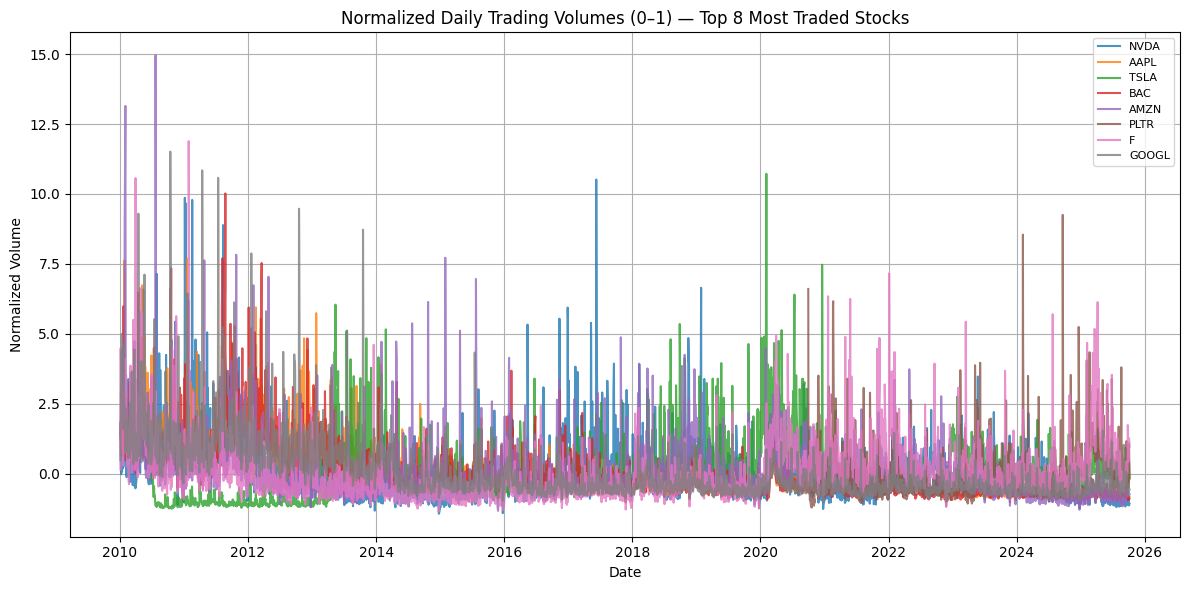

In [140]:
zscore_volume = (top8_volume - top8_volume.mean()) / top8_volume.std()

# NORMALIZED trading volumes
plt.figure(figsize=(12,6))
for ticker in zscore_volume.columns:
    plt.plot(zscore_volume.index, zscore_volume[ticker], label=ticker, alpha=0.8)

plt.title('Normalized Daily Trading Volumes (0–1) — Top 8 Most Traded Stocks')
plt.xlabel('Date')
plt.ylabel('Normalized Volume')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

With the applied z-score normalization, patterns within daily trading volumes can be identified. The visibl peaks represent each stock’s relative highs rather than absolute volumes, emphasizing periods of intense investor focus. 

Most stocks show broad, **market-wide spikes in 2009–2012**, then a quieter middle period. NVDA has renewed clusters around 2017–2019, consistent with the first big AI/GPU wave and the introduction of such tools as ChatGPT. Tesla's (TSLA) relative activity surges 2019–2021, due to such factors as index inclusion and retail momentum, while Palantir Technologies Inc (PLTR) exhibits post-2020 spikes typical of a newly listed name. Ford Motor Co (F) shows recurring bursts during 2021–2022. Amazon (AMZN), in contrast, displays a more stable yet event-driven trading pattern. Its volume rises modestly during major corporate developments, such as earnings releases, expansions in AWS and pandemic-related surges in e-commerce activity.

Overall, the chart suggests that **trading activity** in the top S&P 500 names is **episodic and event-driven**, often tied to **technological innovation, macroeconomic shifts** or company-specific factors such as **earnings announcements and major product releases**.

### Reshaping the dataset

In [141]:
price = new_df['Close']          # shape: (dates × tickers)
volume = new_df['Volume']                  # shape: (dates × tickers)

wide = pd.concat({'Price': price, 'Volume': volume}, axis=1)
wide.columns.names = ['Field', 'Ticker']   # name the column levels for clarity

long = (wide
        .stack('Ticker')                   # index becomes (Date, Ticker)
        .rename_axis(index=['Date', 'Ticker'])
        .reset_index())                    # columns: Date, Ticker, Price, Volume

long = long[long['Ticker'] != '^SPX']

long['Date'] = pd.to_datetime(long['Date'])
long = long.sort_values(['Date']).dropna(subset=['Price', 'Volume'])

long.head()

C:\Users\lasko\AppData\Local\Temp\ipykernel_41732\3098469954.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack('Ticker')                   # index becomes (Date, Ticker)


Field,Date,Ticker,Price,Volume
0,2010-01-04,A,19.891680,3815561.0
290,2010-01-04,O,11.949985,904961.0
289,2010-01-04,NVR,712.669983,61900.0
288,2010-01-04,NVDA,0.423830,800204000.0
287,2010-01-04,NUE,31.190182,4923600.0


### Scaling the data

We decided to tackle the prediction task using Logistic Regression to predict the probabilities of positive / negative returns, therefore to scale the data, we'll be using **StandardScaler** as a slightly more common and often more stable choice for LR, which standardizes to zero mean and unit variance.

In [142]:
scaler = StandardScaler()

def scale_group(g):
    sc = StandardScaler()
    g[['Price_scaled','Volume_scaled']] = sc.fit_transform(g[['Price','Volume']])
    return g

long = long.groupby('Ticker', group_keys=False).apply(scale_group)
long = long.reset_index(drop=True)
long.head()

C:\Users\lasko\AppData\Local\Temp\ipykernel_41732\3691037560.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long = long.groupby('Ticker', group_keys=False).apply(scale_group)


Field,Date,Ticker,Price,Volume,Price_scaled,Volume_scaled
0,2010-01-04,A,19.891680,3815561.0,-1.161079,0.497504
1,2010-01-04,O,11.949985,904961.0,-1.787414,-0.740138
2,2010-01-04,NVR,712.669983,61900.0,-1.014680,1.534511
3,2010-01-04,NVDA,0.423830,800204000.0,-0.501674,1.035483
4,2010-01-04,NUE,31.190182,4923600.0,-0.763419,1.691551


## Task #2 : Train and Test samples + Logistic Regression

Tagrets:

In [143]:
# Daily returns per stock
long['Return_1d'] = long.groupby('Ticker')['Price'].pct_change()

# Future returns (5, 20, 60 days ahead)
for horizon in [5, 20, 60]:
    long[f'Future_Return_{horizon}d'] = long.groupby('Ticker')['Price'].pct_change(periods=horizon).shift(-horizon)
    long[f'Target_{horizon}d'] = (long[f'Future_Return_{horizon}d'] > 0).astype(int)

long.head()

Field,Date,Ticker,Price,Volume,Price_scaled,Volume_scaled,Return_1d,Future_Return_5d,Target_5d,Future_Return_20d,Target_20d,Future_Return_60d,Target_60d
0,2010-01-04,A,19.891680,3815561.0,-1.161079,0.497504,NaN,NaN,0,NaN,0,NaN,0
1,2010-01-04,O,11.949985,904961.0,-1.787414,-0.740138,NaN,NaN,0,NaN,0,NaN,0
2,2010-01-04,NVR,712.669983,61900.0,-1.014680,1.534511,NaN,NaN,0,NaN,0,NaN,0
3,2010-01-04,NVDA,0.423830,800204000.0,-0.501674,1.035483,NaN,NaN,0,NaN,0,NaN,0
4,2010-01-04,NUE,31.190182,4923600.0,-0.763419,1.691551,NaN,NaN,0,NaN,0,NaN,0


Past Features:

In [144]:
for lag in [5, 20, 60]:
    long[f'Return_mean_{lag}d'] = long.groupby('Ticker')['Return_1d'].transform(lambda x: x.rolling(lag).mean())
    long[f'Volume_mean_{lag}d'] = long.groupby('Ticker')['Volume_scaled'].transform(lambda x: x.rolling(lag).mean())

long.head()

Field,Date,Ticker,Price,Volume,Price_scaled,Volume_scaled,Return_1d,Future_Return_5d,Target_5d,Future_Return_20d,Target_20d,Future_Return_60d,Target_60d,Return_mean_5d,Volume_mean_5d,Return_mean_20d,Volume_mean_20d,Return_mean_60d,Volume_mean_60d
0,2010-01-04,A,19.891680,3815561.0,-1.161079,0.497504,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,O,11.949985,904961.0,-1.787414,-0.740138,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,NVR,712.669983,61900.0,-1.014680,1.534511,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,NVDA,0.423830,800204000.0,-0.501674,1.035483,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-04,NUE,31.190182,4923600.0,-0.763419,1.691551,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
print(len(long))

long = long.dropna(subset=[
    'Return_mean_5d', 'Volume_mean_5d', 
    'Return_mean_20d', 'Volume_mean_20d',
    'Return_mean_60d', 'Volume_mean_60d',
    'Target_5d', 'Target_20d', 'Target_60d'
])

print(len(long))

1883021
1852841


### We'll first focus on the **5-day horizons**:

In [146]:
long = long.sort_values('Date')

# Features and target
features = [
    'Return_mean_5d', 'Volume_mean_5d'
]

X = long[features]
y = long['Target_5d']

###  Split the sample : 75% training, 25% testing

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

### Logistic Regression

In [148]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities (column 1 = probability of "positive return")
y_prob = model.predict_proba(X_test)[:, 1]

### Alternative measures: 
Number of time the predicted return and the realized return have the same sign - **Accuracy**:

In [149]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)

Accuracy: 0.6046359002700713


array([[ 84390, 131341],
       [ 51796, 195684]])

In [150]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.39      0.48    215731
           1       0.60      0.79      0.68    247480

    accuracy                           0.60    463211
   macro avg       0.61      0.59      0.58    463211
weighted avg       0.61      0.60      0.59    463211



In [151]:
long.loc[X_test.index, 'Predicted_Class_LR'] = y_pred
long.loc[X_test.index, 'Predicted_Prob_LR'] = y_prob

The model seems **more confident identifying uptrends**, which could align with general market drift - the S&P 500 tends to rise more often than fall.

However, **missing many down moves could be problematic** for short-selling or hedging strategies.

In trading, **false positives—cases** where the model predicts a price rise but the stock actually falls—can **lead to real financial losses**. To **mitigate this risk**, it’s often better to **err on the side of caution** by adjusting the model’s decision threshold. **Raising the classification threshold** reduces the number of “up” predictions, which lowers recall for positive returns but improves the model’s ability to correctly identify negative return periods. This trade-off prioritizes risk management, aligning the model’s behavior with **more conservative investment strategies**.

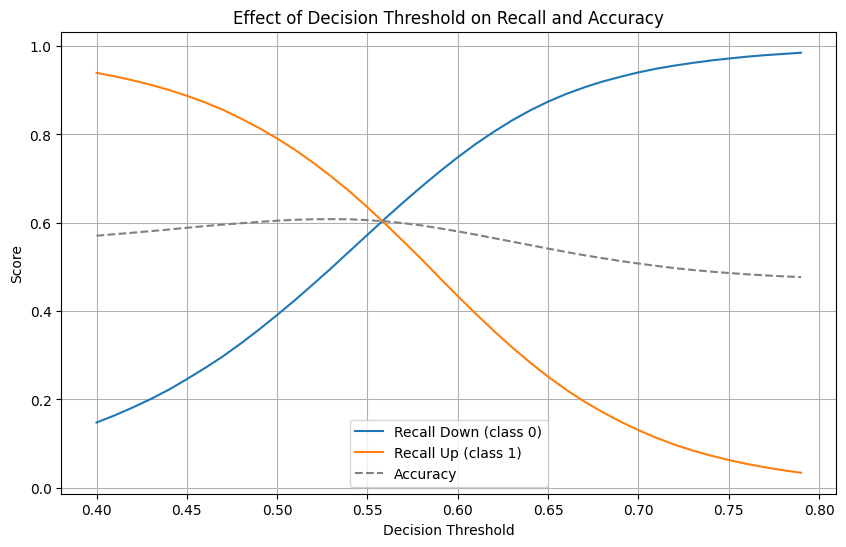

In [152]:
recall_0 = []
recall_1 = []
acc = []


thresholds = np.arange(0.4, 0.8, 0.01)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall_0.append(recall_score(y_test, y_pred_t, pos_label=0))
    recall_1.append(recall_score(y_test, y_pred_t, pos_label=1))
    acc.append(accuracy_score(y_test, y_pred_t))

plt.figure(figsize=(10,6))
plt.plot(thresholds, recall_0, label='Recall Down (class 0)')
plt.plot(thresholds, recall_1, label='Recall Up (class 1)')
plt.plot(thresholds, acc, label='Accuracy', linestyle='--', color='gray')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Effect of Decision Threshold on Recall and Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Our goal is to set the threshold so that:

- We maximize recall for class 0 (detecting down moves)

- Keep overall accuracy reasonable (not too many false alarms)

In [153]:
scores = np.array(recall_0) * 0.7 + np.array(acc) * 0.3
best_t = thresholds[np.argmax(scores)]
print("Balanced threshold:", best_t)

Balanced threshold: 0.7900000000000004


Let's run the Logistic Regression with the **new threshold = 0.79**:

In [154]:
threshold = 0.79
y_pred = (y_prob >= threshold).astype(int)

# Evaluate
print(f"Threshold used: {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Threshold used: 0.79
Accuracy: 0.4768906610594308

Confusion Matrix:
 [[212482   3249]
 [239061   8419]]

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.98      0.64    215731
           1       0.72      0.03      0.06    247480

    accuracy                           0.48    463211
   macro avg       0.60      0.51      0.35    463211
weighted avg       0.60      0.48      0.33    463211



### Plot - Predicted vs Realized - **Apple**

In [155]:
apple = long[long['Ticker'] == 'AAPL'].copy()
apple['Realized'] = (apple['Future_Return_5d'] > 0).astype(int)
apple = apple.sort_values('Date')

plt.figure(figsize=(12,6))

# Plot predicted probabilities of positive return
plt.plot(apple['Date'], apple['Predicted_Prob'], label='Predicted Probability (Up)', color='tab:blue', alpha=0.8)

# Plot realized outcomes (1 = up, 0 = down)
plt.plot(apple['Date'], apple['Realized'], label='Realized Direction (Up=1, Down=0)', color='tab:orange', alpha=0.6)

# Add a random prediction line for baseline comparison
np.random.seed(42)
random_preds = np.random.rand(len(apple))
plt.plot(apple['Date'], random_preds, label='Random Baseline', color='gray', linestyle='--', alpha=0.7)

# Add decision threshold line (optional)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Decision Threshold (0.5)')

plt.title('Predicted vs. Realized 5-Day Direction — AAPL')
plt.xlabel('Date')
plt.ylabel('Probability / Realized Direction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'Predicted_Prob'

<Figure size 1200x600 with 0 Axes>